In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set()

# Ejercicio de clasificación usando kNN

Tenemos el dataset de incumplimiento de clientes para una compañía de tarjetas de crédito. De cada cliente se tiene el balance que le llegó de la tarjeta, si es un estudiante universitario o no y el sueldo anual. Además, contamos si el cliente incumplió el pago o no. Este dataset es el usado en regresión logística en Inteligencia Artificial.

### Modelo de regresión logística

Para tener un punto de comparación, usemos el modelo de regresión logística realizado en Inteligencia Artificial.

In [22]:
# Cargar dataset
df = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_final.csv")
test_df = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_final_test.csv")


# Suponiendo que tenés un DataFrame df con la columna "Arrest_tag"
df_majority = df[df['Arrest_tag'] == 0]
df_minority = df[df['Arrest_tag'] == 1]

# Tomamos el mismo número de casos de la mayoría que de la minoría
df_majority_downsampled = df_majority.sample(
    n=len(df_minority), 
    random_state=42
)

# Combinamos ambas
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Mezclamos para no quedar con bloques homogéneos
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)



X = df_balanced.drop(["Arrest_tag"], axis=1)
y = df_balanced["Arrest_tag"]

X_test = test_df.drop(["Arrest_tag"], axis=1)
y_test = test_df["Arrest_tag"]

In [37]:
# como siempre vamos separando nuestras variables predictoras de la variable a predecir
X_train = X
y_train = y

In [38]:
model_logistic = LogisticRegression(random_state = 0, class_weight="balanced")
model_logistic.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
y_pred = model_logistic.predict(X_test)

# Creamos la matriz de confusión
cm_logistic = confusion_matrix(y_test, y_pred)

/opt/homebrew/anaconda3/envs/add-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


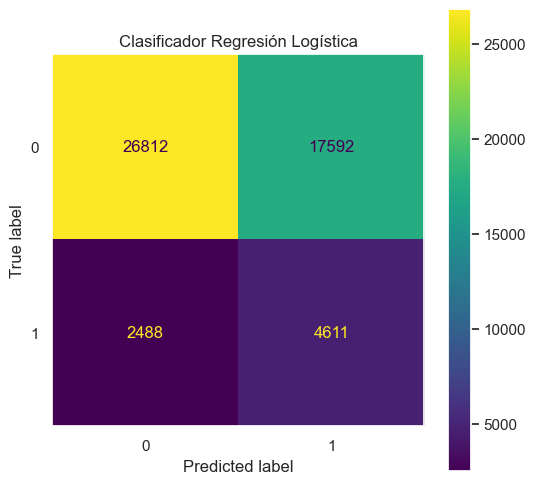

In [40]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic,
                              display_labels=model_logistic.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador Regresión Logística");

In [41]:
# Midamos la sensibilidad y especificidad
print("Clasificador Regresión Logística")
P = np.sum(cm_logistic[1, :])
N = np.sum(cm_logistic[0, :])
TP = cm_logistic[1, 1]
TN = cm_logistic[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Clasificador Regresión Logística
Sensibilidad: 0.6495281025496549
Especificidad: 0.6038194757229078
Exactitud balanceada: 0.6266737891362814
Precision: 0.20767463856235643
Recuperación: 0.6495281025496549
F1-score: 0.3147225445362091


## Clasificador KNN

Vamos a usar el clasificador KNN de [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html). Para este ejemplo, vamos a usar el mismo dataset de la regresión logistica.

In [42]:
# Entrenamos
from sklearn.neighbors import KNeighborsClassifier

classifier_knn = KNeighborsClassifier(n_neighbors=23, metric="minkowski", p=2)
classifier_knn.fit(X_train, y_train)

,n_neighbors,23
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [43]:
#Evaluamos
y_pred  = classifier_knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred)

/opt/homebrew/anaconda3/envs/add-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


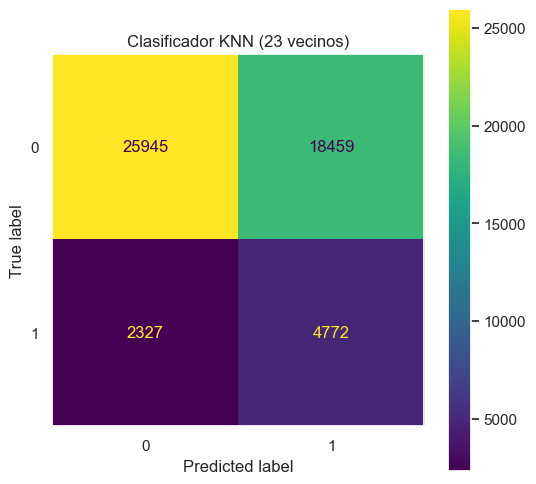

In [44]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels=classifier_knn.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador KNN (23 vecinos)");

In [45]:
# Midamos la sensibilidad y especificidad
print("Clasificador KNN (23 vecinos)")
P = np.sum(cm_knn[1, :])
N = np.sum(cm_knn[0, :])
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Clasificador KNN (23 vecinos)
Sensibilidad: 0.6722073531483308
Especificidad: 0.5842942077290334
Exactitud balanceada: 0.6282507804386821
Precision: 0.20541517799492057
Recuperación: 0.6722073531483308
F1-score: 0.3146719419716452


Veamos la frontera de decisión

In [46]:
X_train_two, X_test_two, y_train_two, y_test_two = X_train, X_test, y_train, y_test

sc_X = StandardScaler()
X_train_two = sc_X.fit_transform(X_train_two)

classifier_knn_two = KNeighborsClassifier(n_neighbors=31, metric="minkowski", p=2)
classifier_knn_two.fit(X_train_two, y_train_two)

,n_neighbors,31
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None
